# SPY ETF Performance Analysis
### End-to-End Data Science Workflow (Define → Collect → Explore → Clean → Analyze → Visualize → Conclude)

**Dataset:** SPY (SPDR S&P 500 ETF Trust) daily OHLCV prices, sourced from `ETF_prices.csv`.
**Period covered:** 1993-01-29 to 2021-11-30 (7,263 trading days).


## 1. Define the Problem

**Objective:** Analyze SPY's historical daily price and volume data to understand its price behavior, risk profile, and trading patterns.

**Questions we want to answer:**
- How has SPY's closing price evolved over time?
- What does the daily return distribution look like — is risk symmetric?
- How volatile is SPY, and what were its best/worst trading days?
- Is there a relationship between trading volume and daily price moves?
- On what fraction of days did SPY close up vs. down?


## 2. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor":   "#1a1a2e",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#e0e0e0",
    "grid.color":       "#2a2a4a",
    "figure.dpi":       150,
})

print("Libraries loaded successfully")

Libraries loaded successfully


## 3. Load Dataset

The source file `ETF_prices.csv` contains daily prices for 2,310 different ETFs.
We isolate a single fund — **SPY** — to keep the analysis focused (7,263 rows, well under the 10k-row working limit).


In [2]:
raw_df = pd.read_csv("ETF_prices.csv")

print(f"Full file shape : {raw_df.shape}")
print(f"Unique funds    : {raw_df['fund_symbol'].nunique()}")

df = raw_df[raw_df["fund_symbol"] == "SPY"].copy()
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values("price_date").reset_index(drop=True)

print(f"\nSPY subset shape : {df.shape}")
df.head()

Full file shape : (3866030, 8)
Unique funds    : 2310



SPY subset shape : (7263, 8)


,fund_symbol,price_date,open,high,low,close,adj_close,volume
0,SPY,1993-01-29,43.97,43.97,43.75,43.94,25.80,1003200
1,SPY,1993-02-01,43.97,44.25,43.97,44.25,25.98,480500
2,SPY,1993-02-02,44.22,44.38,44.12,44.34,26.04,201300
3,SPY,1993-02-03,44.41,44.84,44.38,44.81,26.31,529400
4,SPY,1993-02-04,44.97,45.09,44.47,45.00,26.42,531500


## 4. Explore Dataset

In [3]:
print("Info:")
df.info()

Info:
<class 'pandas.DataFrame'>
RangeIndex: 7263 entries, 0 to 7262
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   fund_symbol  7263 non-null   str           
 1   price_date   7263 non-null   datetime64[us]
 2   open         7263 non-null   float64       
 3   high         7263 non-null   float64       
 4   low          7263 non-null   float64       
 5   close        7263 non-null   float64       
 6   adj_close    7263 non-null   float64       
 7   volume       7263 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1), str(1)
memory usage: 454.1 KB


In [4]:
print("Descriptive statistics:")
df.describe().T

Descriptive statistics:


,count,mean,min,25%,50%,75%,max,std
price_date,7263,2007-06-28 18:35:50.185873,1993-01-29 00:00:00,2000-04-06 12:00:00,2007-06-29 00:00:00,2014-09-15 12:00:00,2021-11-30 00:00:00,NaN
open,7263.0,152.477403,43.34,101.3,128.62,194.62,470.89,85.566423
high,7263.0,153.363236,43.53,102.16,129.28,195.505,473.54,85.915335
low,7263.0,151.49278,42.81,100.185,127.72,193.315,468.5,85.181556
close,7263.0,152.479367,43.41,101.395,128.57,194.455,469.73,85.58256
adj_close,7263.0,127.28202,25.49,71.42,94.23,171.84,469.73,91.868333
volume,7263.0,84200539.418973,5200.0,8285400.0,58783300.0,118992300.0,871026300.0,95299697.204102


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
fund_symbol    0
price_date     0
open           0
high           0
low            0
close          0
adj_close      0
volume         0
dtype: int64

Duplicate rows: 0


## 5. Clean Data

Standard checks for missing values, duplicates, and dtype correctness. SPY's data is already
clean (0 missing values, 0 duplicates), but the pipeline below is written defensively so it would
still work on a messier fund.


In [6]:
df_clean = df.copy()

# Drop exact duplicate rows, if any
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df_clean)}")

# Forward-fill any missing prices (last known price), then back-fill leading gaps
price_cols = ["open", "high", "low", "close", "adj_close"]
df_clean[price_cols] = df_clean[price_cols].ffill().bfill()
df_clean["volume"] = df_clean["volume"].fillna(df_clean["volume"].median())

# Set a DatetimeIndex for time-series operations
df_clean.set_index("price_date", inplace=True)
df_clean.drop(columns=["fund_symbol"], inplace=True)

assert df_clean.isnull().sum().sum() == 0, "FATAL: residual NaNs after cleaning"
print("Cleaning complete — 0 missing values remain")
df_clean.head()

Duplicates removed: 0
Cleaning complete — 0 missing values remain


,open,high,low,close,adj_close,volume
price_date,,,,,,
1993-01-29,43.97,43.97,43.75,43.94,25.80,1003200
1993-02-01,43.97,44.25,43.97,44.25,25.98,480500
1993-02-02,44.22,44.38,44.12,44.34,26.04,201300
1993-02-03,44.41,44.84,44.38,44.81,26.31,529400
1993-02-04,44.97,45.09,44.47,45.00,26.42,531500


## 6. Analyze Data

In [7]:
df_a = df_clean.copy()

# Daily return (%)
df_a["daily_return_pct"] = df_a["close"].pct_change() * 100

highest_close = df_a["close"].max()
highest_close_date = df_a["close"].idxmax()
lowest_close = df_a["close"].min()
lowest_close_date = df_a["close"].idxmin()

avg_volume = df_a["volume"].mean()
avg_return = df_a["daily_return_pct"].mean()
volatility = df_a["daily_return_pct"].std()

best_day = df_a["daily_return_pct"].idxmax()
worst_day = df_a["daily_return_pct"].idxmin()

up_days = (df_a["daily_return_pct"] > 0).sum()
down_days = (df_a["daily_return_pct"] < 0).sum()
flat_days = (df_a["daily_return_pct"] == 0).sum()

print(f"Highest close : ${highest_close:,.2f} on {highest_close_date.date()}")
print(f"Lowest close  : ${lowest_close:,.2f} on {lowest_close_date.date()}")
print(f"Average volume: {avg_volume:,.0f} shares/day")
print(f"Average daily return: {avg_return:.3f}%")
print(f"Daily volatility (std): {volatility:.3f}%")
print(f"Best day  : {best_day.date()}  ({df_a.loc[best_day, 'daily_return_pct']:.2f}%)")
print(f"Worst day : {worst_day.date()}  ({df_a.loc[worst_day, 'daily_return_pct']:.2f}%)")
print(f"\nUp days   : {up_days} ({up_days/len(df_a)*100:.1f}%)")
print(f"Down days : {down_days} ({down_days/len(df_a)*100:.1f}%)")
print(f"Flat days : {flat_days} ({flat_days/len(df_a)*100:.1f}%)")

Highest close : $469.73 on 2021-11-18
Lowest close  : $43.41 on 1993-02-18
Average volume: 84,200,539 shares/day
Average daily return: 0.039%
Daily volatility (std): 1.182%
Best day  : 2008-10-13  (14.52%)
Worst day : 2020-03-16  (-10.94%)

Up days   : 3897 (53.7%)
Down days : 3305 (45.5%)
Flat days : 60 (0.8%)


## 7. Visualize Data

**7.1 — SPY Closing Price Over Time**

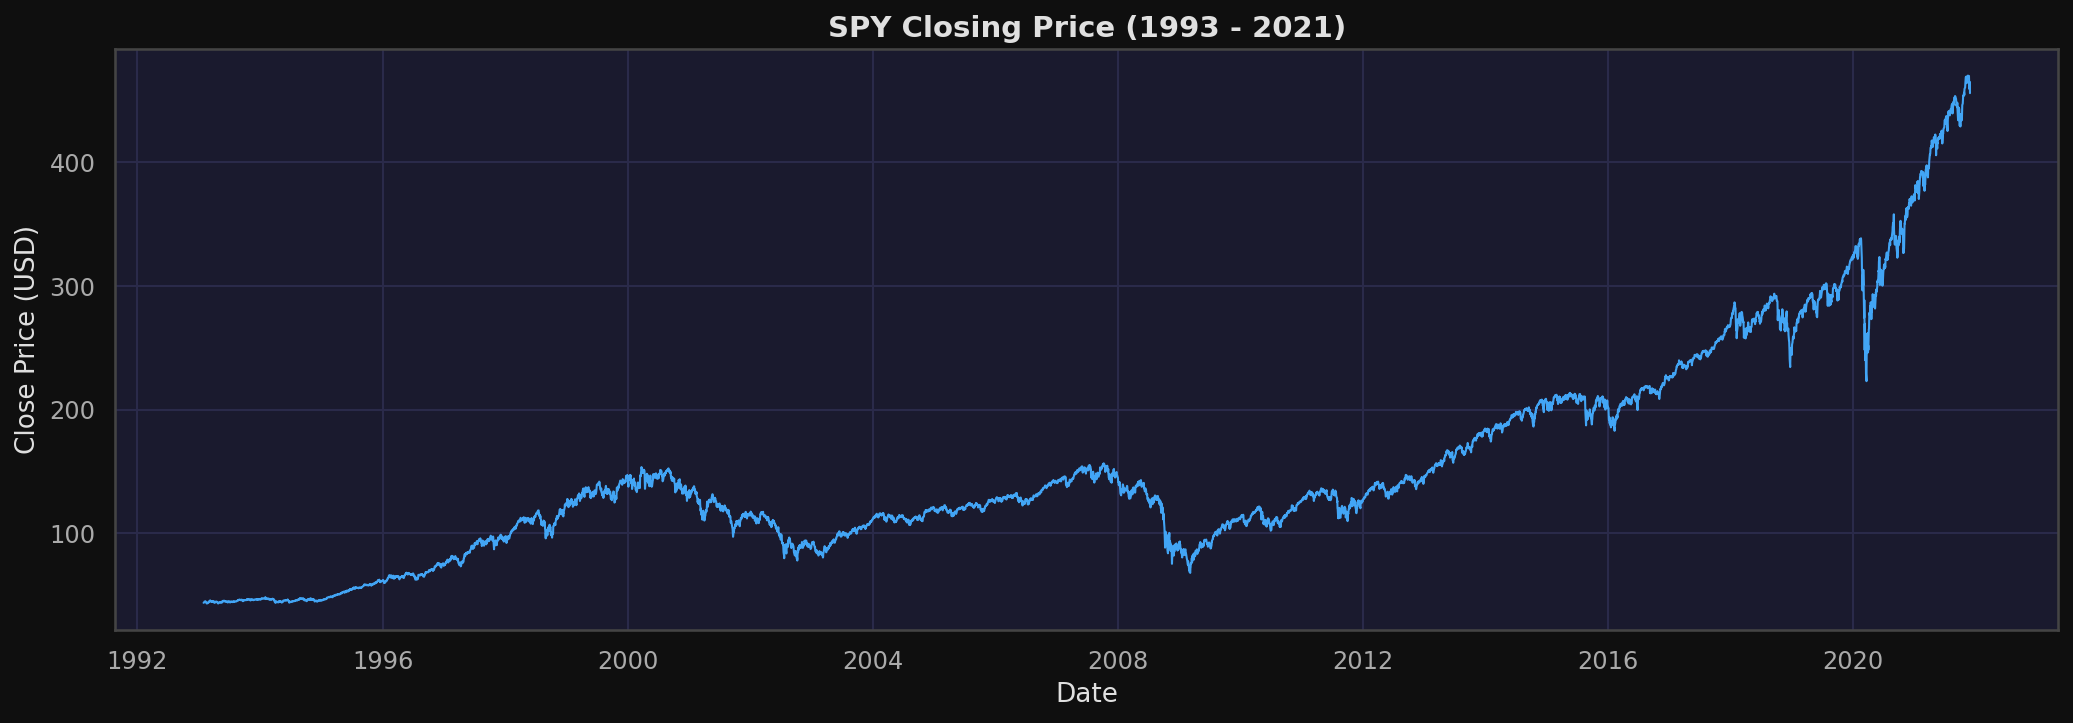

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(df_a.index, df_a["close"], color="#42a5f5", lw=1)
plt.title("SPY Closing Price (1993 - 2021)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.tight_layout()
plt.savefig("outputs/01_spy_close_price.png", bbox_inches="tight")
plt.show()

**7.2 — Daily Return Distribution**

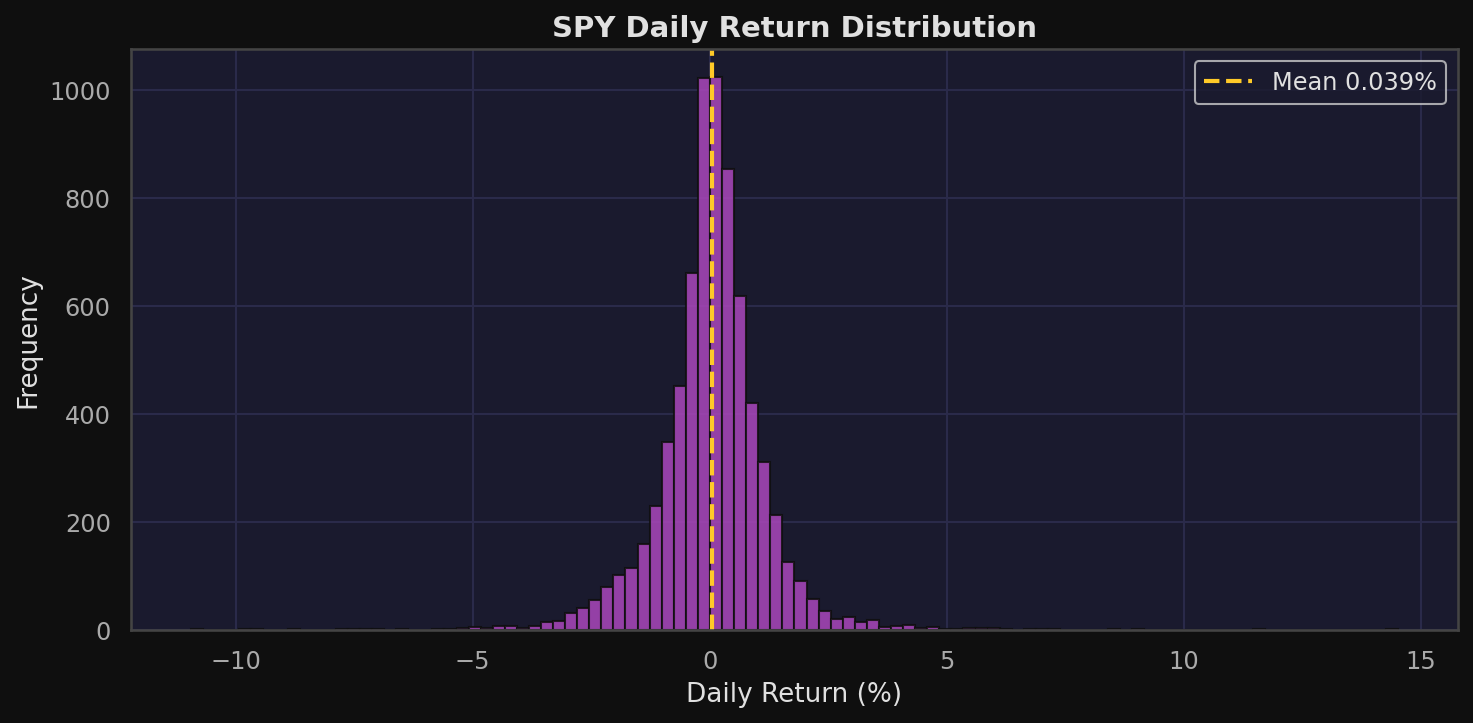

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(df_a["daily_return_pct"].dropna(), bins=100, color="#ab47bc", edgecolor="#0f0f0f", alpha=0.85)
plt.axvline(avg_return, color="#ffca28", lw=2, ls="--", label=f"Mean {avg_return:.3f}%")
plt.title("SPY Daily Return Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/02_daily_return_distribution.png", bbox_inches="tight")
plt.show()

**7.3 — Trading Volume Distribution**

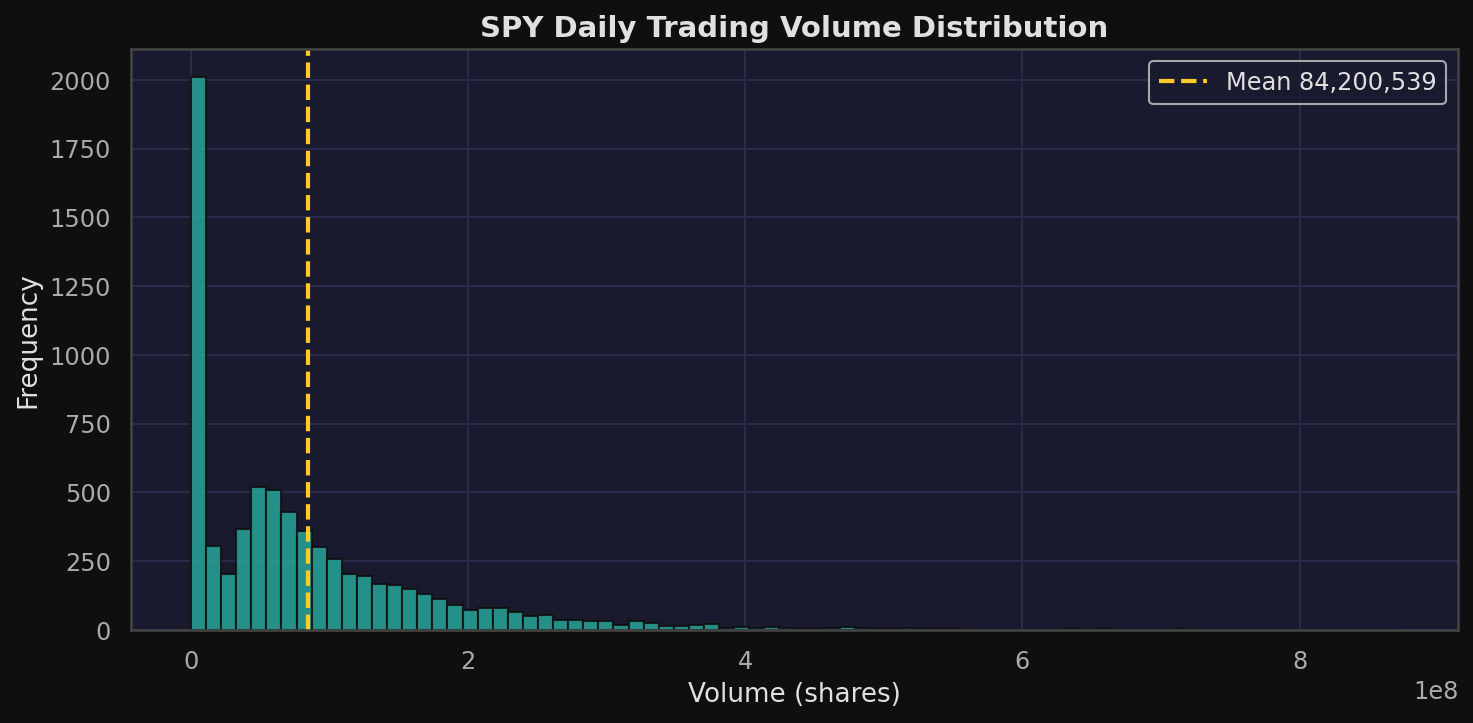

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df_a["volume"], bins=80, color="#26a69a", edgecolor="#0f0f0f", alpha=0.85)
plt.axvline(avg_volume, color="#ffca28", lw=2, ls="--", label=f"Mean {avg_volume:,.0f}")
plt.title("SPY Daily Trading Volume Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Volume (shares)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/03_volume_distribution.png", bbox_inches="tight")
plt.show()

**7.4 — Up Days vs Down Days**

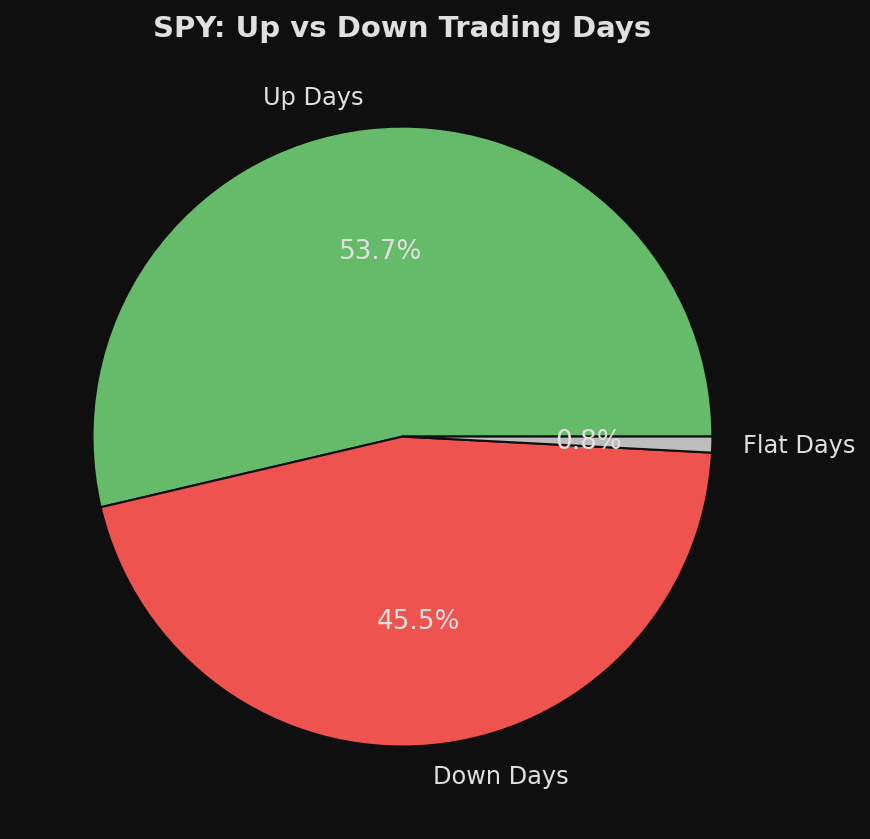

In [11]:
labels = ["Up Days", "Down Days", "Flat Days"]
sizes = [up_days, down_days, flat_days]
colors = ["#66bb6a", "#ef5350", "#bdbdbd"]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=colors,
        wedgeprops={"edgecolor": "#0f0f0f", "linewidth": 1})
plt.title("SPY: Up vs Down Trading Days", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/04_up_vs_down_days.png", bbox_inches="tight")
plt.show()

**7.5 — Volume vs Daily Return**

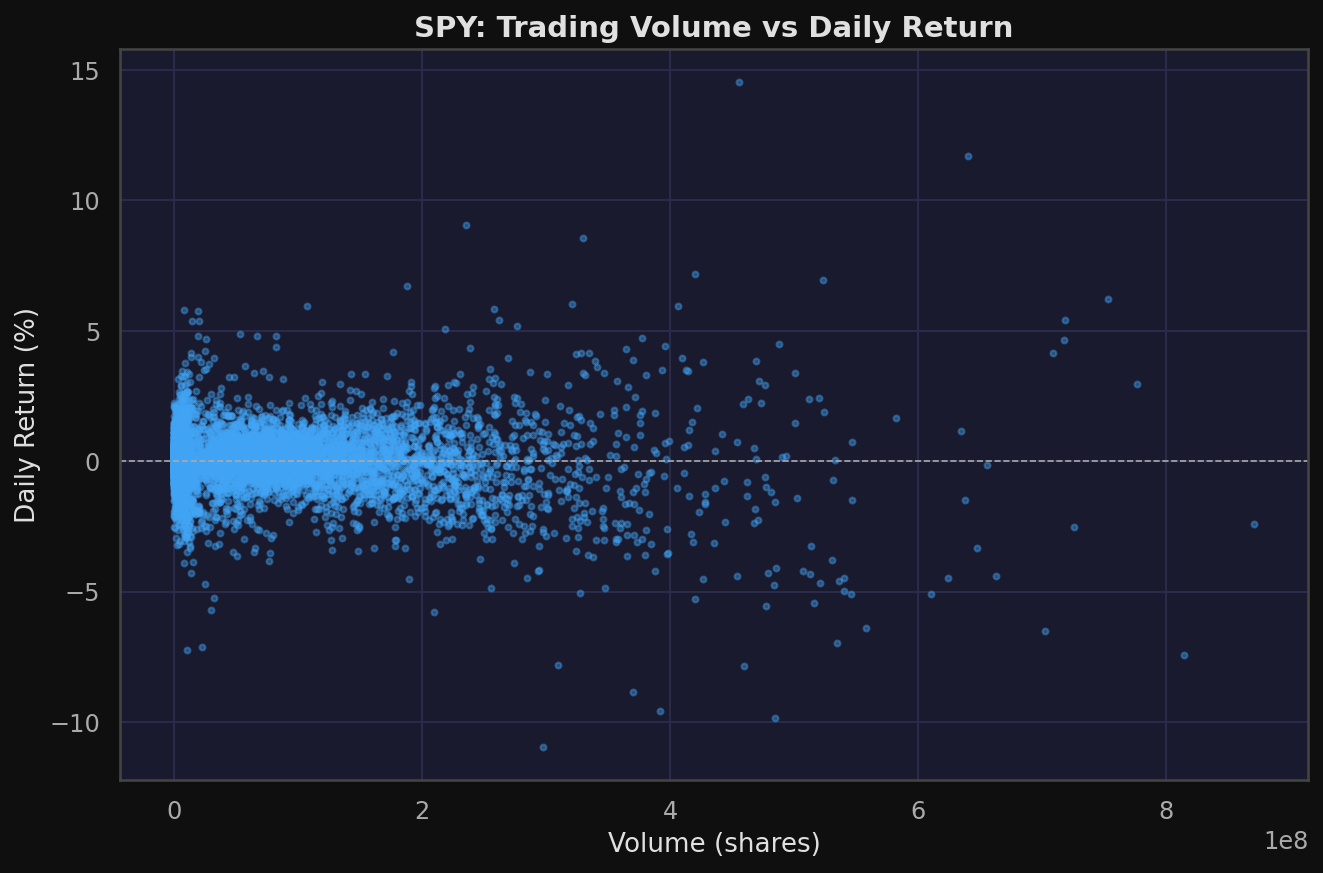

In [12]:
plt.figure(figsize=(9, 6))
plt.scatter(df_a["volume"], df_a["daily_return_pct"], s=8, alpha=0.4, color="#42a5f5")
plt.axhline(0, color="#aaa", lw=0.8, ls="--")
plt.title("SPY: Trading Volume vs Daily Return", fontsize=14, fontweight="bold")
plt.xlabel("Volume (shares)")
plt.ylabel("Daily Return (%)")
plt.tight_layout()
plt.savefig("outputs/05_volume_vs_return.png", bbox_inches="tight")
plt.show()

## 8. Draw Conclusions

- SPY's closing price shows a long-term uptrend from 1993 to 2021, consistent with the S&P 500's historical growth, punctuated by sharp drawdowns during the Dot-Com Crash, 2008 Financial Crisis, and the 2020 COVID crash.
- Daily returns are tightly clustered around zero with a slight positive mean, but the distribution has fat tails — large single-day moves (both up and down) are more frequent than a normal distribution would predict, a hallmark of financial return series.
- SPY closed higher slightly more often than it closed lower, consistent with its long-run positive drift.
- Trading volume is right-skewed: most days see moderate volume, with occasional volume spikes tied to volatile market periods.
- No strong linear relationship is visible between volume and same-day return — high-volume days occur on both up and down moves, though the largest return outliers do tend to coincide with elevated volume, suggesting volume spikes around major market-moving events.


## 9. Final Output

In [13]:
df_a.to_csv("outputs/spy_cleaned_analyzed.csv")

report = '''SPY ETF Analysis — Summary Report
-----------------------------------
Period analyzed: {start} to {end}  ({n} trading days)
Highest close: ${high:.2f} on {high_date}
Lowest close: ${low:.2f} on {low_date}
Average daily return: {avg_ret:.3f}%
Daily volatility (std): {vol:.3f}%
Up days: {up} ({up_pct:.1f}%)  |  Down days: {down} ({down_pct:.1f}%)
Best single day: {best_day} ({best_val:.2f}%)
Worst single day: {worst_day} ({worst_val:.2f}%)

SPY shows a long-term uptrend with fat-tailed daily returns typical of equity markets.
Volume spikes align with the market's most volatile trading days.
'''.format(
    start=df_a.index.min().date(), end=df_a.index.max().date(), n=len(df_a),
    high=highest_close, high_date=highest_close_date.date(),
    low=lowest_close, low_date=lowest_close_date.date(),
    avg_ret=avg_return, vol=volatility,
    up=up_days, up_pct=up_days/len(df_a)*100,
    down=down_days, down_pct=down_days/len(df_a)*100,
    best_day=best_day.date(), best_val=df_a.loc[best_day, 'daily_return_pct'],
    worst_day=worst_day.date(), worst_val=df_a.loc[worst_day, 'daily_return_pct'],
)

with open("outputs/summary_report.txt", "w") as f:
    f.write(report)

print(report)
print("Saved: outputs/spy_cleaned_analyzed.csv")
print("Saved: outputs/summary_report.txt")

SPY ETF Analysis — Summary Report
-----------------------------------
Period analyzed: 1993-01-29 to 2021-11-30  (7263 trading days)
Highest close: $469.73 on 2021-11-18
Lowest close: $43.41 on 1993-02-18
Average daily return: 0.039%
Daily volatility (std): 1.182%
Up days: 3897 (53.7%)  |  Down days: 3305 (45.5%)
Best single day: 2008-10-13 (14.52%)
Worst single day: 2020-03-16 (-10.94%)

SPY shows a long-term uptrend with fat-tailed daily returns typical of equity markets.
Volume spikes align with the market's most volatile trading days.

Saved: outputs/spy_cleaned_analyzed.csv
Saved: outputs/summary_report.txt
